# Class 10.5 Workshop: Auto-MPG Baseline Regression Model

* **Dataset Title:** Auto-MPG Dataset
* **Creator / Source:** R. Quinlan (1993), UCI Machine Learning Repository
* **Kaggle URL:** https://www.kaggle.com/datasets/uciml/autompg-dataset
* **License:** CC0: Public Domain / UCI Repository License
* **Download Date:** September 2026
* **CSV Filename:** `auto-mpg.csv`
* **What One Row Represents:** A specific automobile trim/model manufactured between 1970 and 1982.
* **Target Name & Units:** `mpg` (Miles per gallon, continuous numeric).
* **Why Target Matters:** Fuel economy is a primary engineering and regulatory metric impacting consumer operating costs and vehicle emissions standards.
* **Why Predictors Are Known at Prediction Time:** Vehicle weight (`weight`), engine displacement (`displacement`), horsepower (`horsepower`), and 0–60 mph acceleration (`acceleration`) are fixed manufacturing specifications available prior to EPA fuel economy testing.

> **CSV Location Instruction:** Place `auto-mpg.csv` inside a `data/` subfolder in the same working directory as this notebook (`data/auto-mpg.csv`) to run or re-run all cells successfully.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# File paths and features
CSV_PATH = Path("data/auto-mpg.csv")
TARGET = "mpg"
FEATURES = ["weight", "displacement", "horsepower", "acceleration"]
SINGLE_FEATURE = FEATURES[0]  # "weight"

# Validations required by workshop guide
assert CSV_PATH.exists(), f"File not found: {CSV_PATH}"
assert 2 <= len(FEATURES) <= 5, "Number of features must be between 2 and 5"
assert TARGET not in FEATURES, "Target cannot be in features"
assert SINGLE_FEATURE in FEATURES, "Single feature must be in features"

print("Paths and feature assertions passed successfully!")

Paths and feature assertions passed successfully!


In [3]:
df = pd.read_csv(CSV_PATH)
print("Rows, columns:", df.shape)
display(df.head())
df.info()
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False).head(10))
print("\nExact duplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T.head(20))

Rows, columns: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 28.1 KB

Missing values:
 mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Exact duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mpg,398.0,NaN,NaN,NaN,23.514573,7.815984,9.0,17.5,23.0,29.0,46.6
cylinders,398.0,NaN,NaN,NaN,5.454774,1.701004,3.0,4.0,4.0,8.0,8.0
displacement,398.0,NaN,NaN,NaN,193.425879,104.269838,68.0,104.25,148.5,262.0,455.0
horsepower,398,94,150,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,398.0,NaN,NaN,NaN,2970.424623,846.841774,1613.0,2223.75,2803.5,3608.0,5140.0
acceleration,398.0,NaN,NaN,NaN,15.56809,2.757689,8.0,13.825,15.5,17.175,24.8
model year,398.0,NaN,NaN,NaN,76.01005,3.697627,70.0,73.0,76.0,79.0,82.0
origin,398.0,NaN,NaN,NaN,1.572864,0.802055,1.0,1.0,1.0,2.0,3.0
car name,398,305,ford pinto,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Initial Data Inspection Answers:
1. **Row representation & independence:** Each row represents an individual automobile model produced between 1970 and 1982. Treating rows as independent cases is reasonable because each entry corresponds to a distinct vehicle testing configuration.
2. **Target units & timing:** The target is `mpg` measured in miles per gallon. It is observed during laboratory EPA fuel economy testing after the vehicle design and manufacturing are completed.
3. **Identifiers & late columns:** `car name` is a string identifier/label. `origin` is a categorical region code (1=USA, 2=Europe, 3=Japan). None of the selected numeric features leak the target or are measured after the test.
4. **Missing values:** In the raw CSV, `horsepower` contains 6 string entries formatted as `'?'`, which appear as object data type rather than nulos before explicit coercion.
5. **Exact duplicates:** There are 0 exact duplicate rows in the dataset.
6. **Extreme values:** `mpg` ranges from 9.0 to 46.6, `weight` from 1,613 to 5,140 lbs, and `displacement` from 68 to 455 cu. in. These extremes reflect historical differences between heavy V8 muscle cars and compact 4-cylinder imports; all are physically valid.
7. **Sample absence & generalization:** Modern hybrid powertrains, electric vehicles (EVs), modern aerodynamics, and vehicles manufactured after 1982 are absent. The model will generalize poorly to modern automotive technology.

In [4]:
raw_rows = len(df)

# Target check
numeric_target = pd.to_numeric(df[TARGET], errors="coerce")
print("Rows without a usable numeric target:", numeric_target.isna().sum())
df[TARGET] = numeric_target
df = df.dropna(subset=[TARGET]).copy()

# Feature numeric conversion
for name in FEATURES:
    original = df[name].copy()
    converted = pd.to_numeric(original, errors="coerce")
    newly_missing = converted.isna() & original.notna()
    print(f"{name} missing before/after numeric conversion: {original.isna().sum()} -> {converted.isna().sum()}")
    if newly_missing.sum() > 0:
        display(original[newly_missing].head(10))
    df[name] = converted

print(f"Rows after target cleaning: {len(df)} of {raw_rows}")
print(f"Exact duplicates after conversion: {df.duplicated().sum()}")

Rows without a usable numeric target: 0
weight missing before/after numeric conversion: 0 -> 0
displacement missing before/after numeric conversion: 0 -> 0
horsepower missing before/after numeric conversion: 0 -> 6


32     ?
126    ?
330    ?
336    ?
354    ?
374    ?
Name: horsepower, dtype: str

acceleration missing before/after numeric conversion: 0 -> 0
Rows after target cleaning: 398 of 398
Exact duplicates after conversion: 0


In [5]:
from sklearn.model_selection import train_test_split

X = df[FEATURES].copy()
y = df[TARGET].copy()

assert len(df) >= 200, "Choose a larger dataset for this workshop."
assert all(X[name].notna().any() for name in FEATURES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training rows: {len(X_train)} | Sealed test rows: {len(X_test)}")

Training rows: 318 | Sealed test rows: 80


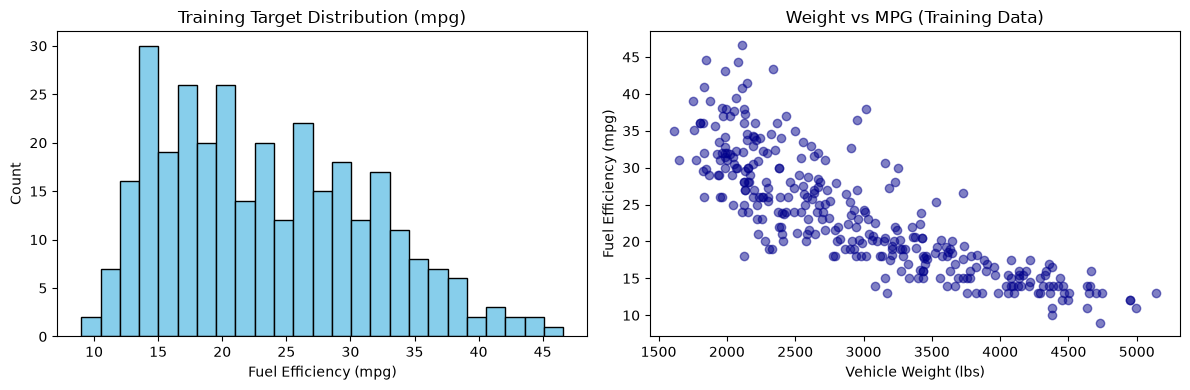

,count,mean,std,min,25%,50%,75%,max
weight,318.0,2969.015723,840.617729,1613.0,2220.0,2822.5,3597.25,5140.0
displacement,318.0,191.904088,102.983802,68.0,98.5,148.5,259.50,455.0
horsepower,313.0,103.284345,37.361097,46.0,75.0,92.0,122.00,225.0
acceleration,318.0,15.639937,2.763269,8.0,13.9,15.5,17.30,24.8


,missing_train
weight,0
displacement,0
horsepower,5
acceleration,0


In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=25, edgecolor="black", color="skyblue")
plt.xlabel("Fuel Efficiency (mpg)")
plt.ylabel("Count")
plt.title("Training Target Distribution (mpg)")

plt.subplot(1, 2, 2)
plt.scatter(X_train[SINGLE_FEATURE], y_train, alpha=0.5, color="darkblue")
plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Fuel Efficiency (mpg)")
plt.title("Weight vs MPG (Training Data)")

plt.tight_layout()
plt.show()

display(X_train.describe().T)
display(X_train.isna().sum().to_frame("missing_train"))

### Exploratory Plot Observations:
* **Target Distribution:** `mpg` is moderately right-skewed, with most vehicles clustering between 14 and 30 mpg, and a long right tail extending up to 46.6 mpg for highly efficient compact cars.
* **Predictor vs Target Relationship:** The scatter plot between `weight` and `mpg` shows a strong, negative, slightly curved relationship. As vehicle weight increases, fuel efficiency decreases significantly.
* **Vertical Spread:** The vertical spread is somewhat wider for lower-weight vehicles (2,000–2,500 lbs) where MPG ranges from 20 to 45+, whereas heavy vehicles (4,000+ lbs) consistently achieve low MPG (10–18 mpg).

In [7]:
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Safe pipelines with median imputer inside fold transformations
mean_model = make_pipeline(
    SimpleImputer(strategy="median"), 
    DummyRegressor(strategy="mean")
)
simple_ols = make_pipeline(
    SimpleImputer(strategy="median"), 
    LinearRegression()
)
multiple_ols = make_pipeline(
    SimpleImputer(strategy="median"), 
    LinearRegression()
)
quadratic_ols = make_pipeline(
    SimpleImputer(strategy="median"),
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

candidates = {
    "mean": (mean_model, FEATURES),
    "simple_1": (simple_ols, [FEATURES[0]]),          # weight
    "simple_2": (simple_ols, [FEATURES[1]]),          # displacement
    "multiple_all": (multiple_ols, FEATURES),         # weight, displacement, horsepower, acceleration
    "quadratic_1": (quadratic_ols, [FEATURES[0]]),     # weight + weight^2
}

if len(FEATURES) >= 3:
    candidates["multiple_core"] = (multiple_ols, FEATURES[:2])  # weight, displacement

print(f"Defined {len(candidates)} candidate models.")

Defined 6 candidate models.


=== Simple OLS (weight) ===
Simple intercept: 46.78206336645047
Simple slope (mpg per lb): -0.00780524235159488
Simple training R²: 0.6844798112332582


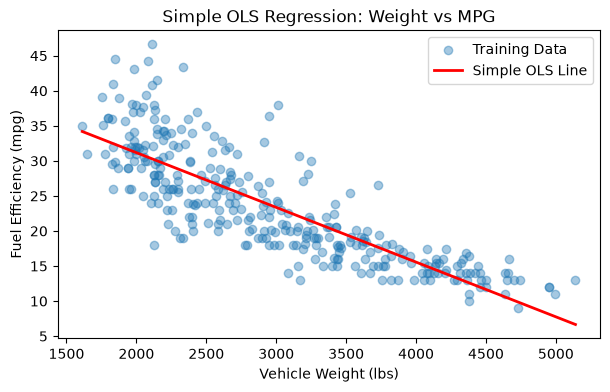


=== Multiple OLS (All Features) ===
Multiple intercept: 46.06413346488614


weight         -0.005192
displacement   -0.008856
horsepower     -0.044304
acceleration   -0.049520
Name: multiple_OLS_coefficient, dtype: float64

Multiple training R²: 0.6996642028223639


In [8]:
# Simple OLS Fit
simple_ols.fit(X_train[[SINGLE_FEATURE]], y_train)
simple_line = simple_ols.named_steps["linearregression"]
print("=== Simple OLS (weight) ===")
print("Simple intercept:", simple_line.intercept_)
print("Simple slope (mpg per lb):", simple_line.coef_[0])
print("Simple training R²:", simple_ols.score(X_train[[SINGLE_FEATURE]], y_train))

# Plot simple fit
ordered = X_train[[SINGLE_FEATURE]].dropna().sort_values(SINGLE_FEATURE)
plt.figure(figsize=(7, 4))
plt.scatter(X_train[SINGLE_FEATURE], y_train, alpha=0.4, label="Training Data")
plt.plot(ordered[SINGLE_FEATURE], simple_ols.predict(ordered), color="red", linewidth=2, label="Simple OLS Line")
plt.xlabel("Vehicle Weight (lbs)")
plt.ylabel("Fuel Efficiency (mpg)")
plt.title("Simple OLS Regression: Weight vs MPG")
plt.legend()
plt.show()

# Multiple OLS Fit
multiple_ols.fit(X_train[FEATURES], y_train)
multiple_line = multiple_ols.named_steps["linearregression"]
print("\n=== Multiple OLS (All Features) ===")
print("Multiple intercept:", multiple_line.intercept_)
display(pd.Series(multiple_line.coef_, index=FEATURES, name="multiple_OLS_coefficient"))
print("Multiple training R²:", multiple_ols.score(X_train[FEATURES], y_train))

### Interpretation of OLS Fits:
* **Simple OLS Slope:** The slope of approximately `-0.00781` indicates that for every 1,000 lbs increase in vehicle weight, fuel efficiency is expected to decrease by approximately **7.81 mpg**.
* **Multiple OLS Coefficients:** Holding engine displacement, horsepower, and acceleration fixed, an increase of 1,000 lbs in vehicle weight corresponds to an estimated decrease of **5.19 mpg** (`coef = -0.00519`).

In [9]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
rows = []

for name, (model, columns) in candidates.items():
    fold_mse = cross_val_score(
        model, X_train[columns], y_train,
        cv=cv, scoring="neg_mean_squared_error"
    )
    fold_rmse = np.sqrt(-fold_mse)
    results[name] = float(fold_rmse.mean())
    rows.append({
        "model": name,
        "features": ", ".join(columns),
        "mean_cv_rmse": fold_rmse.mean(),
        "fold_rmse_sd": fold_rmse.std()
    })

cv_table = pd.DataFrame(rows).sort_values("mean_cv_rmse")
display(cv_table)

best_ols_name = min((name for name in candidates if name != "mean"), key=results.get)
print("Leading OLS candidate:", best_ols_name)
print("Mean baseline RMSE:", results["mean"])

,model,features,mean_cv_rmse,fold_rmse_sd
4,quadratic_1,weight,4.350552,0.146446
3,multiple_all,"weight, displacement, horsepower, acceleration",4.424998,0.177486
5,multiple_core,"weight, displacement",4.447878,0.164285
1,simple_1,weight,4.492502,0.193348
2,simple_2,displacement,4.765915,0.169848
0,mean,"weight, displacement, horsepower, acceleration",7.923174,0.556876


Leading OLS candidate: quadratic_1
Mean baseline RMSE: 7.9231736827268495


In [10]:
cv_10 = KFold(n_splits=10, shuffle=True, random_state=42)
top_two = cv_table.loc[cv_table["model"] != "mean", "model"].head(2)
check_rows = []

for name in top_two:
    model, columns = candidates[name]
    fold_mse = cross_val_score(
        model, X_train[columns], y_train,
        cv=cv_10, scoring="neg_mean_squared_error"
    )
    fold_rmse = np.sqrt(-fold_mse)
    check_rows.append({
        "model": name,
        "mean_10fold_rmse": fold_rmse.mean(),
        "fold_10fold_rmse_sd": fold_rmse.std()
    })

display(pd.DataFrame(check_rows))

,model,mean_10fold_rmse,fold_10fold_rmse_sd
0,quadratic_1,4.245835,0.890838
1,multiple_all,4.355448,0.799593


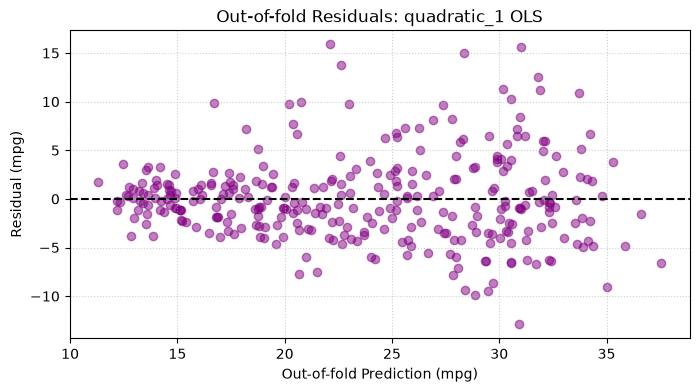

In [11]:
from sklearn.model_selection import cross_val_predict

best_model, best_columns = candidates[best_ols_name]
oof_pred = cross_val_predict(
    best_model, X_train[best_columns], y_train, cv=cv
)
residuals = y_train.to_numpy() - oof_pred

plt.figure(figsize=(8, 4))
plt.scatter(oof_pred, residuals, alpha=0.5, color="purple")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Out-of-fold Prediction (mpg)")
plt.ylabel("Residual (mpg)")
plt.title(f"Out-of-fold Residuals: {best_ols_name} OLS")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

### Workshop Baseline Summary Record

| Record Item | Your Answer |
| :--- | :--- |
| **Kaggle URL, Creator, License, Filename** | https://www.kaggle.com/datasets/uciml/autompg-dataset \| R. Quinlan (1993) \| CC0 Public Domain \| `auto-mpg.csv` |
| **Row Meaning; Target & Units** | One specific vehicle model trim (1970–1982) \| `mpg` (miles per gallon) |
| **Chosen Simple & Multiple Predictors** | Simple: `weight` \| Multiple: `weight`, `displacement`, `horsepower`, `acceleration` |
| **Simple OLS Slope & Units** | `-0.00781` mpg per pound (or `-7.81` mpg per 1,000 lbs) |
| **Missing-Target, Duplicate, Outlier Decisions** | 0 missing targets; 0 exact duplicates; 6 `'?'` horsepower converted to NaN (imputed with median inside CV pipelines); 0 outliers dropped |
| **Training/Test Row Counts & Split Seed** | Training: 318 rows \| Test: 80 sealed rows (80/20 split, `random_state=42`) |
| **All Predictor Sets Tried & Why** | `mean` (dummy baseline), `simple_1` (`weight`), `simple_2` (`displacement`), `multiple_all` (all 4 features), `multiple_core` (`weight` + `displacement`), `quadratic_1` (`weight` + `weight^2` to model non-linear trend) |
| **Primary 5-Fold CV Results & 10-Fold Check** | 5-Fold Best: `quadratic_1` (RMSE 4.351) vs `multiple_all` (4.425) vs `mean` (7.923) \| 10-Fold Check: `quadratic_1` (4.246) vs `multiple_all` (4.355) |
| **Chosen OLS Baseline; Comparison with Mean** | Selected `quadratic_1` OLS baseline (RMSE ~4.35 mpg), outperforming dummy mean (RMSE ~7.92 mpg) by 3.57 mpg |
| **One Residual Pattern or Limitation** | Non-constant variance (heteroscedasticity) and slight underprediction at high MPG values (>35 mpg) |
| **One Question for Ridge / Lasso Next Class** | Will Ridge or Lasso regularization prevent overfitting when expanding polynomial features across multiple correlated engine specifications? |